데이터 수집/분석 플로우

1. 데이터 수집
- crawling with python (requests, bs4, selenium, scrapy)
- open API (공공데이터포털, 네이버, 카카오 등의 정보값 수집 활용)
- Reseatch (구글폼, 데스크리서치)

2. 데이터 저장
- RDBMS (MySQL)
- NoSQL (MongoBD)

3. 데이터 구조
- PlanText, json, xml, csv

4. 탐색적 데이터 분석
- EDA

5. 데이터 전처리(정체)
- Pnadas in python (1차원 serise, 2차원 dataframe)

6. 데이터 시각화
- plotly in python

matpltlib, seaborn -> 과거에 많이 사용했던 라이브러리 모듈

plotly = matpltlib + seaborn 

1) plotly express
- 장점 : 간단한 코드를 입력해서 빠르게 EDA를 하고자할 때 사용 / 빠르고 간단한 시각화
- 단점 : 그래프 혹은 차트의 저알한 수정, 편집이 불가능

2. plotly graph objects
- 장점 : 시각화 그래프 차트의 종류가 다양하다 / 세밀하고 다양한 시각화
- 단점 : express대비 코드가 길고 복잡하다


plotly express 추가옵션

1) fig.update_layout() : 전체 레이아웃(제목, 범례, 여백 등)을 수정/편집 -> title, legend
2) fig.update_xaxes() : x축의 속성(제목, 글꼴, 눈금 등)을 수정/편집 -> title_text, title_font, tickangle, dtick
3) fig.update_yaxes() : y축의 속성(제목, 글꼴, 눈금 등)을 수정/편집

In [1]:
# 라이브러리 설치

!pip install plotly

1. plotly express 기본 코드 패턴

import plotly.express as px

fig = px.그래프종류(
    데이터프레임, -> pandas를 통해서 생성된 데이터프레임 
    x='x축 이름',
    y='y축 이름',
    title='전체 그래프|차트 제목'
)

fig.show() -> 위에서 설정한 그래프 값을 출력시켜주는 명령 매서드

2. plotly express에서 자주 사용하는 그래프 | 차트 종류
- 차트에 정답은 없고, 단지 이런 경우에 많이 사용한다는 참고 정도 하면 될듯
- 종류가 많아서 많이 쓰는 것 위주로 봄

1) 산점도 그래프 (scatter)
> 각 데이터간 상관관계를 분석하거나 전체 데이터의 밀집도를 확인하고 싶을 때 사용
> ex.매출대비 이익에 대한 상관관계 분석, 판매하는 상품의 저가 혹은 고가 어느쪽인지 확인하고 싶을 때

px.scatter(df, x='x열', y='y열', color='생상범례값설정')

2) 선 그래프 (line)
> 시계열차트, 시간경과에 따라서 데이터의 증감 추이를 파악하고 싶을 때 사용 / 연속됨
> 과거 데이터를 기반으로 증가, 감소를 알고 싶을 때 (마케팅 예측, 대안 전략수립)
> 주식차트에 많이 사용한다
> 웹사이트 유입 트래픽 -> 어떤 시간대에 많이 유입되는가? 어떤 요일에 많이 구매하는가 등

px.line(df, x='x열', y='y열')

3) 막대 그래프 (bar)
> 서로 다른 데이터들 간 개별적인 수치값을 비교하려고 하는 경우 사용
> 절대빈도 차트 (ex. 학생들의 시험성적을 비교)
> 브랜드별 분기매출 지표 확인

px.bar(df, x='범주열', y='값')

4) 히스토그램 차트 (histogram)
> 과거로 부터 이어져 온 데이터의 누적된 흐름을 보려고 할 떄 사용
> 특정 시점의 앞, 뒤 데이터가 붙어져있어서 전체적인 흐름 판단이 용이하다
> 해당 기간 동안의 데이터의 그룹화 (군집화) 가능 (ex.2년의 기간동안 8개의 그룹으로 나눠서 각 그룹의 수치를 볼 수 있다)

px.histogram(df, x='데이터열', nbins=몇 개의 구간으로 나눠서 데이터를 볼 것인가)

5) 상자그림 (boxplot)
> 특정 데이터 그룹의 최대, 최소, 중앙, 평균 이상치 값을 한번에 박스 형태로 보여준다
> 상자(해당 데이터 그룹의 보편화된 값이 어디에 몰려있는가)
> 이상치(특이값)가 왜 나왔는지, 증가하고 있는지, 감소하고 있는지를 볼 수있다

px.box(df, y=['비교하고자 하는 각 열'])

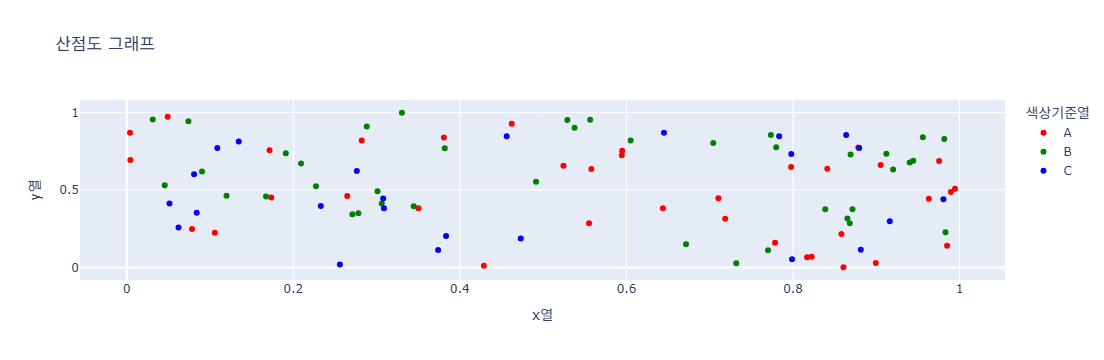

In [6]:
# 산전도

import plotly.express as px
import pandas as pd
import numpy as np # 연산작업을 할 떄 많이 사용 (연산자를 끌어오려고 할 때)

df = pd.DataFrame({
    "x열": np.random.rand(100), # 0부터 1미만의 실수자료형을 난수형태로 100개 생성 (중복허용)
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) # 최대한 비중을 근사치로 만들어준다
})

fig = px.scatter(df, x="x열", y="y열", color="색상기준열", color_discrete_sequence=["red", "green", "blue"],  title="산점도 그래프")
fig.show()

# color_discrete_sequence= : 색상을 고정해서 사용하고 싶을 때 사용

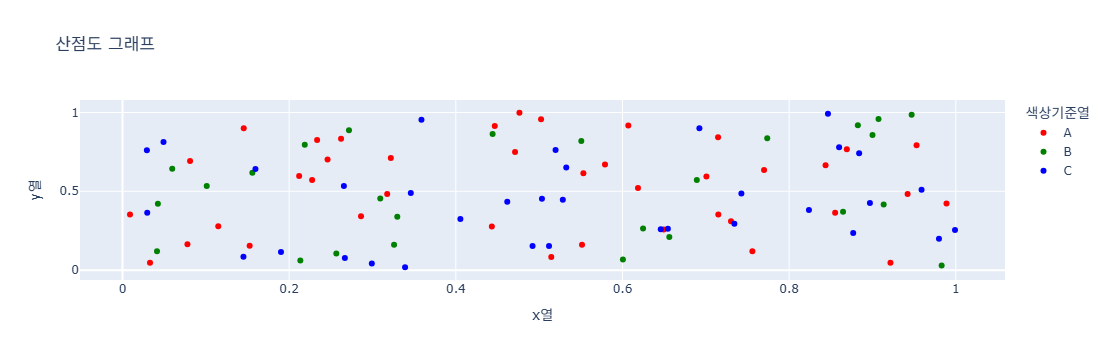

In [21]:
# 산전도

import plotly.express as px
import pandas as pd
import numpy as np 

df = pd.DataFrame({
    "x열": np.random.rand(100), 
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) 
})

# df["색상기준열"] = pd.Categorical(df["색상기준열"], categories=["A", "B", "C"], ordered=True)

fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"],  title="산점도 그래프")
fig.show()

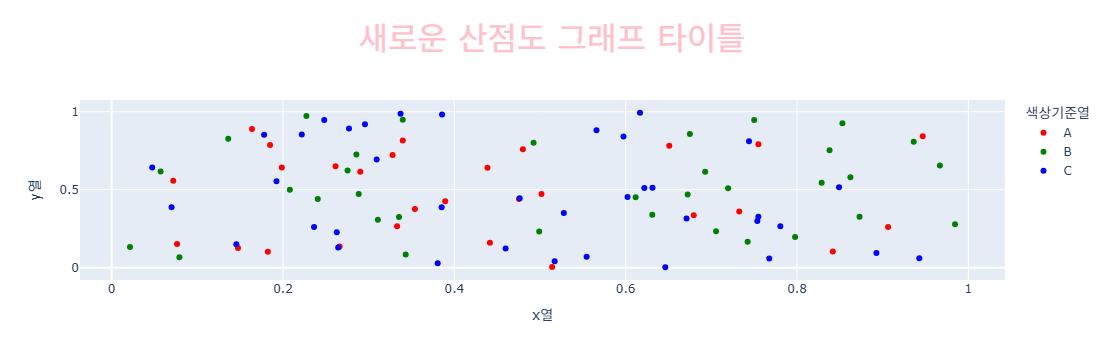

In [30]:
# 산전도그래프 업데이트

import plotly.express as px
import pandas as pd
import numpy as np 

df = pd.DataFrame({
    "x열": np.random.rand(100), 
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) 
})


fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"],  title="산점도 그래프")


# 굳이 이렇게 하는 이유는 위에 구문에선 타이틀명만 지정할수있지 폰트, 컬러 등 다양한 것들을 지정할 수 없기 때문!
fig.update_layout(
    title={
        "text": "새로운 산점도 그래프 타이틀",
        "font": {
            "size": 32,
            "color": "pink"
        },
        "x":0.5 # 중앙정렬
    }
)

fig.show()

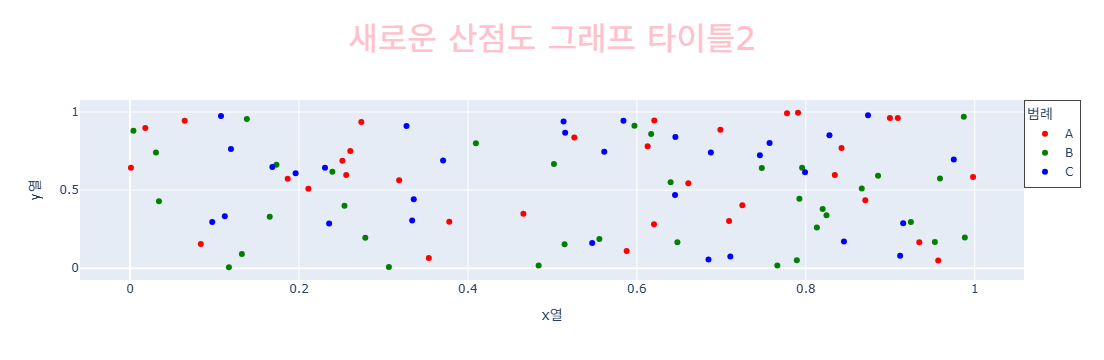

In [43]:
# 산전도그래프 업데이트

import plotly.express as px
import pandas as pd
import numpy as np 

df = pd.DataFrame({
    "x열": np.random.rand(100), 
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) 
})


fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"],  title="산점도 그래프")


# 굳이 이렇게 하는 이유는 위에 구문에선 타이틀명만 지정할수있지 폰트, 컬러 등 다양한 것들을 지정할 수 없기 때문!
fig.update_layout(
    title={
        "text": "새로운 산점도 그래프 타이틀2",
        "font": {
            "size": 32,
            "color": "pink"
        },
        "x":0.5 # 중앙정렬
    },
    legend={
        "title": "범례",
        "x": 1,
        "y": 1,
        "xanchor": "left",
        "yanchor": "top",
        "borderwidth": 1
    }
)

fig.show()

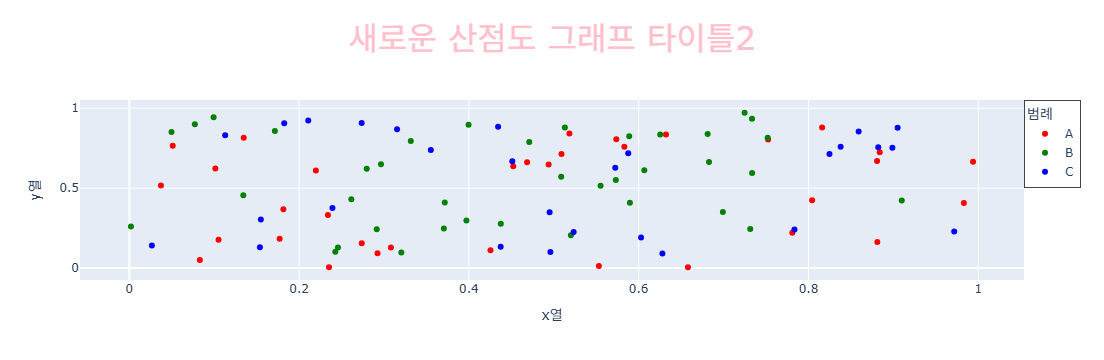

In [44]:
# 산전도그래프 업데이트

import plotly.express as px
import pandas as pd
import numpy as np 

df = pd.DataFrame({
    "x열": np.random.rand(100), 
    "y열": np.random.rand(100),
    "색상기준열": np.random.choice(["A", "B", "C"], 100) 
})


fig = px.scatter(df, x="x열", y="y열", color="색상기준열", category_orders={"색상기준열": ["A", "B", "C"]}, color_discrete_sequence=["red", "green", "blue"],  title="산점도 그래프")


# 굳이 이렇게 하는 이유는 위에 구문에선 타이틀명만 지정할수있지 폰트, 컬러 등 다양한 것들을 지정할 수 없기 때문!
fig.update_layout(
    title={
        "text": "새로운 산점도 그래프 타이틀2",
        "font": {
            "size": 32,
            "color": "pink"
        },
        "x":0.5 # 중앙정렬
    },
    legend=dict(
        title= "범례",
        x= 1,
        y= 1,
        xanchor= "left",
        yanchor= "top",
        borderwidth= 1
    )
)

fig.show()

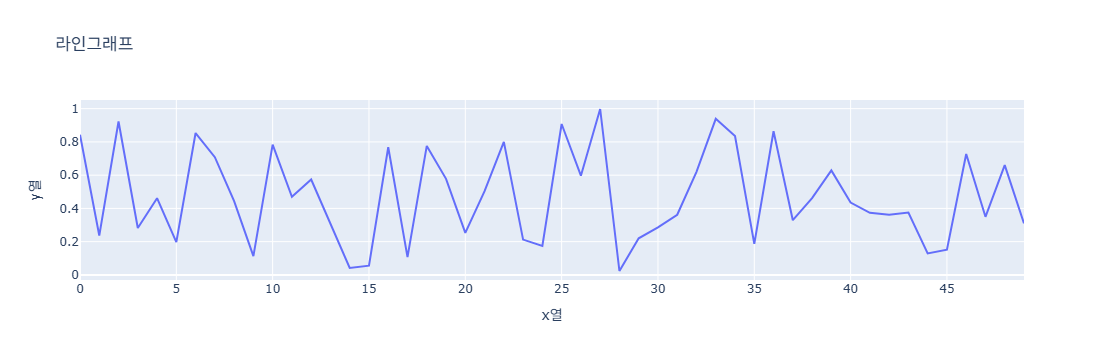

In [10]:
# 라인 차트

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.arange(50), # 0부터 시작해서 49까지 토탈 50개의 정수를 1차원의 배열로 생성 [0, 1, 2, 3, 4, 5, 6, ...49] -> 난수 아님
    "y열": np.random.rand(50) # 0부터 1미만의 실수자료형을 난수형태로 100개 생성 (중복허용)
})

fig = px.line(df, x="x열", y="y열", title="라인그래프")
fig.show()

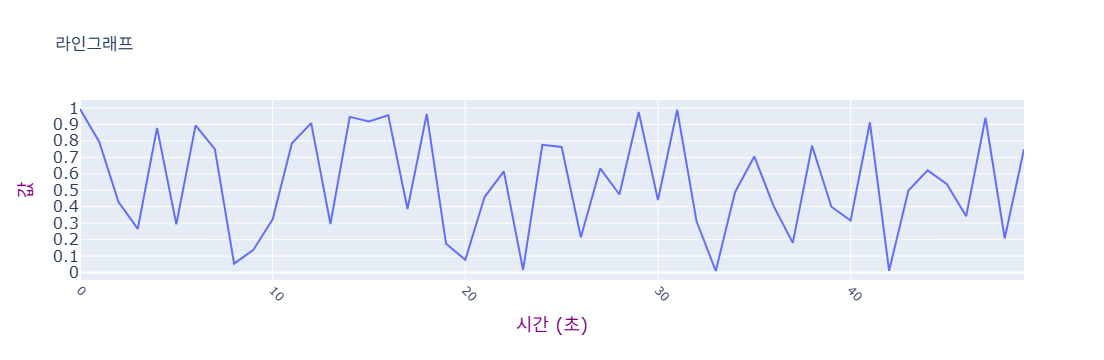

In [53]:
# 라인 차트 수정

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열": np.arange(50), 
    "y열": np.random.rand(50) 
})

fig = px.line(df, x="x열", y="y열", title="라인그래프")

fig.update_xaxes(
    title_text="시간 (초)",
    title_font=dict(size=18, color="purple"),
    tickangle=45,
    dtick=10
)

fig.update_yaxes(
    title_text="값",
    title_font=dict(size=18, color="purple"),
    tickfont=dict(size=16),
    dtick=0.1
)

fig.show()

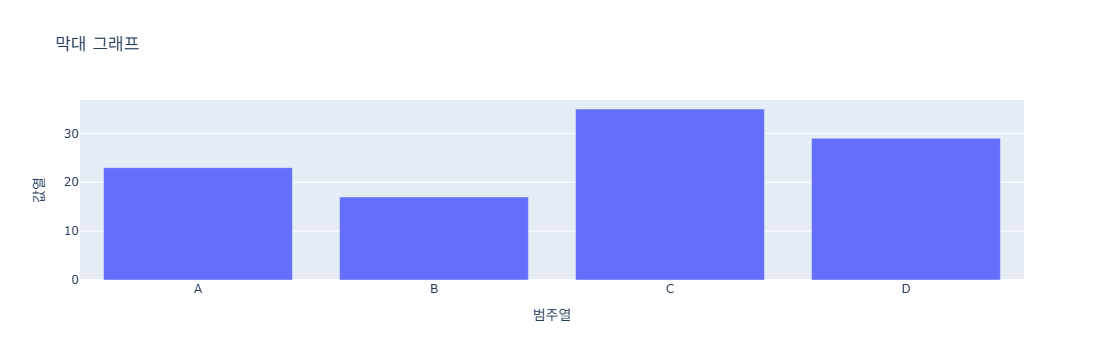

In [11]:
# 막대그래프

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "범주열": ["A", "B", "C", "D"],
    "값열": [23, 17, 35, 29]
})

fig = px.bar(df, x="범주열", y="값열", title="막대 그래프")
fig.show()

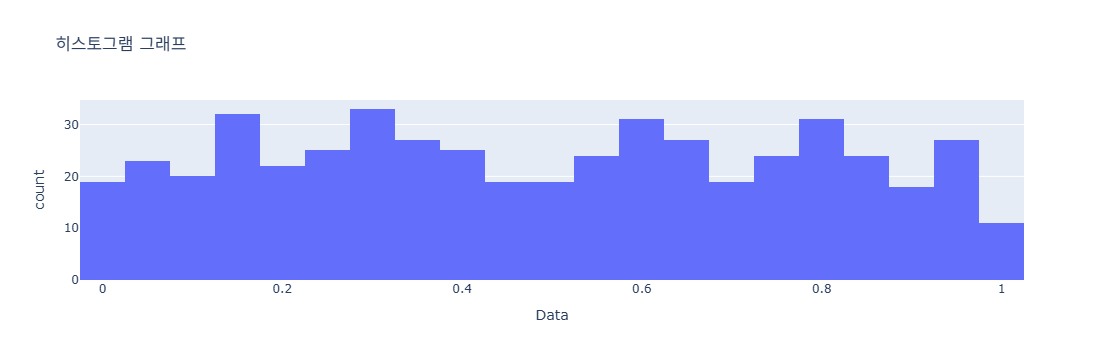

In [16]:
# 히스토그램

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Data":np.random.rand(500)
})

fig = px.histogram(df, x="Data", nbins=30, title="히스토그램 그래프") # nbins=3 : 500개의 숫자를 30개의 섹터로 나눠서 봄

fig.show()

In [22]:
np.random.rand(100) # 0과 1사이의 실수자료형 값을 1차원 배열

array([0.89488533, 0.6804617 , 0.53502841, 0.22728312, 0.02317432,
       0.03893528, 0.7707564 , 0.37599038, 0.10732294, 0.14042971,
       0.80142944, 0.93394765, 0.03567875, 0.27773551, 0.73822577,
       0.72312214, 0.08202537, 0.70586688, 0.93241594, 0.7730178 ,
       0.26698173, 0.29266472, 0.44305775, 0.8608    , 0.26412679,
       0.18855968, 0.26114138, 0.96104943, 0.22310307, 0.11024515,
       0.80826864, 0.71127419, 0.07072915, 0.17272235, 0.34911505,
       0.30310178, 0.95604437, 0.0720478 , 0.71621626, 0.12365373,
       0.99197584, 0.0818439 , 0.89339125, 0.847141  , 0.47003132,
       0.83981982, 0.40641976, 0.6863803 , 0.8810542 , 0.13621442,
       0.49273623, 0.08299413, 0.36438286, 0.20359612, 0.33035315,
       0.45841766, 0.10822809, 0.85116704, 0.49406271, 0.26444919,
       0.8811562 , 0.35707067, 0.25570611, 0.2097792 , 0.02838968,
       0.76819442, 0.9870654 , 0.39486267, 0.87122111, 0.51624332,
       0.71918281, 0.11194092, 0.05998274, 0.30076641, 0.91539

In [25]:
np.random.rand(100, 2) # 100행 2열 / 100값이 2줄

array([[0.42383587, 0.91346392],
       [0.55210213, 0.82167137],
       [0.70332169, 0.36511477],
       [0.91390196, 0.00798072],
       [0.54142821, 0.5487211 ],
       [0.9663465 , 0.93056148],
       [0.19465985, 0.58866441],
       [0.31794732, 0.97782062],
       [0.16517466, 0.61495934],
       [0.82185931, 0.67254842],
       [0.62576525, 0.17821263],
       [0.51922394, 0.33847996],
       [0.35500542, 0.93201474],
       [0.88294933, 0.68434418],
       [0.76153897, 0.766365  ],
       [0.80439539, 0.56075855],
       [0.92540156, 0.37189606],
       [0.59959016, 0.86746035],
       [0.57390925, 0.11753959],
       [0.64350044, 0.19939974],
       [0.89594768, 0.41304505],
       [0.08395304, 0.01831526],
       [0.79121973, 0.32107235],
       [0.94806449, 0.33735905],
       [0.20337171, 0.01138961],
       [0.34062536, 0.29085187],
       [0.01641309, 0.50758365],
       [0.79907083, 0.92841113],
       [0.57725175, 0.16230293],
       [0.94053853, 0.66933775],
       [0.

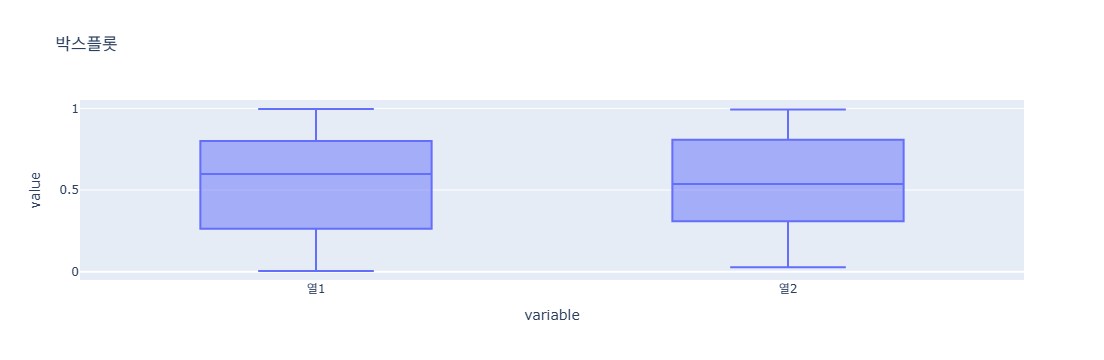

In [26]:
# 박스 플롯

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.rand(100, 2), columns=["열1", "열2"])

fig = px.box(df, y=["열1", "열2"], title="박스플롯")
fig.show()

In [27]:
df

,열1,열2
0,0.202230,0.216925
1,0.746261,0.786949
2,0.073833,0.671607
3,0.779567,0.506135
4,0.783045,0.888789
...,...,...
95,0.119748,0.932404
96,0.741360,0.778222
97,0.583730,0.450320
98,0.970781,0.775163
